# FASE 2: Aprendizaje Supervisado

**Autor:** Jaime Meléndez Zambrano

## Objetivo
Construir clasificadores que predigan la categoría de sentimiento
(placentero / desagradable / mixto) de una respuesta nueva, usando el
corpus etiquetado en la Fase 0 (843 textos, 12 encuestadores).

Se comparan tres modelos clásicos de clasificación de texto: **Naive
Bayes**, **Regresión Logística** y **SVM**, todos entrenados sobre una
representación TF-IDF (unigramas + bigramas).

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('../src'))
from procesador_nlp import ProcesadorNLP
from clasificador import ClasificadorTextos


## Cargar el corpus

In [2]:
procesador = ProcesadorNLP()
textos, etiquetas = procesador.cargar_corpus('../data/corpus_etiquetado')

pd.Series(etiquetas).value_counts()


Corpus cargado: 843 textos
Categorías: ['desagradable', 'mixto', 'placentero']


desagradable    325
placentero      313
mixto           205
Name: count, dtype: int64

## División en entrenamiento y prueba

Se usa `train_test_split` con `stratify=etiquetas` para que la proporción
de cada categoría se mantenga tanto en entrenamiento como en prueba. Con el
corpus ampliado las tres categorías están mucho más balanceadas que antes
(39% / 37% / 24% vs. 56% / 9% / 35%), pero "mixto" sigue siendo la más
pequeña, así que la estratificación sigue siendo importante.

In [3]:
clasificador = ClasificadorTextos(textos, etiquetas)
clasificador.dividir_datos(test_size=0.2)

print()
print("Categorías en entrenamiento:")
print(pd.Series(clasificador.y_train).value_counts())
print()
print("Categorías en prueba:")
print(pd.Series(clasificador.y_test).value_counts())


Entrenamiento: 674 textos
Prueba: 169 textos

Categorías en entrenamiento:
desagradable    260
placentero      250
mixto           164
Name: count, dtype: int64

Categorías en prueba:
desagradable    65
placentero      63
mixto           41
Name: count, dtype: int64


## Entrenar los tres clasificadores

**Nota:** la guía de la tarea sugiere `TfidfVectorizer(stop_words='spanish')`,
pero scikit-learn solo acepta `'english'` como cadena para `stop_words` (o
una lista explícita); `'spanish'` produce `ValueError`. En
`src/clasificador.py` se corrige pasando la lista de stopwords de NLTK en
español.

In [4]:
modelos = clasificador.entrenar_clasificadores()


Modelos entrenados: ['Naive Bayes', 'Logistic Regression', 'SVM']


## Evaluación de los tres modelos

In [5]:
resultados = clasificador.evaluar_modelos()



=== Naive Bayes ===
Precisión: 0.775
              precision    recall  f1-score   support

desagradable       0.83      0.88      0.85        65
       mixto       0.89      0.39      0.54        41
  placentero       0.71      0.92      0.80        63

    accuracy                           0.78       169
   macro avg       0.81      0.73      0.73       169
weighted avg       0.80      0.78      0.76       169


=== Logistic Regression ===
Precisión: 0.787
              precision    recall  f1-score   support

desagradable       0.78      0.94      0.85        65
       mixto       0.90      0.46      0.61        41
  placentero       0.76      0.84      0.80        63

    accuracy                           0.79       169
   macro avg       0.81      0.75      0.75       169
weighted avg       0.80      0.79      0.77       169


=== SVM ===
Precisión: 0.799
              precision    recall  f1-score   support

desagradable       0.77      0.97      0.86        65
       mixto   

## Tabla comparativa de resultados

In [6]:
tabla_resultados = []
for nombre, r in resultados.items():
    macro = r['report']['macro avg']
    tabla_resultados.append({
        "Modelo": nombre,
        "Precisión (accuracy)": round(r['accuracy'], 3),
        "Recuerdo (macro)": round(macro['recall'], 3),
        "F1-score (macro)": round(macro['f1-score'], 3),
    })
tabla_resultados_df = pd.DataFrame(tabla_resultados)
tabla_resultados_df


,Modelo,Precisión (accuracy),Recuerdo (macro),F1-score (macro)
0,Naive Bayes,0.775,0.729,0.731
1,Logistic Regression,0.787,0.748,0.754
2,SVM,0.799,0.764,0.771


## Matriz de confusión del mejor modelo

Mejor modelo: SVM


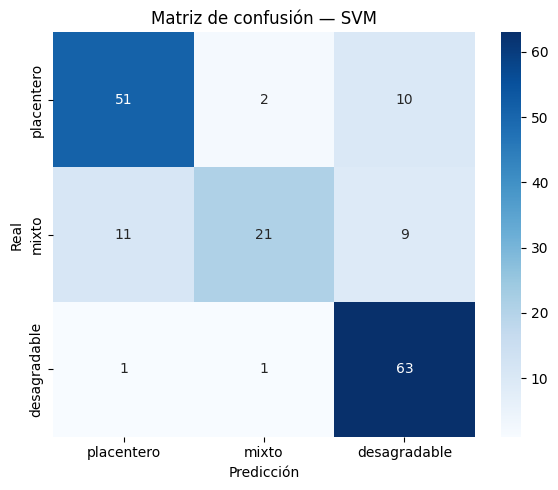

In [7]:
mejor_modelo = tabla_resultados_df.sort_values("F1-score (macro)", ascending=False).iloc[0]["Modelo"]
print("Mejor modelo:", mejor_modelo)

orden_categorias = ['placentero', 'mixto', 'desagradable']
matriz = clasificador.matriz_confusion(mejor_modelo, etiquetas_orden=orden_categorias)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=orden_categorias, yticklabels=orden_categorias)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de confusión — {mejor_modelo}')
plt.tight_layout()
plt.show()


## Características (palabras) más importantes por categoría

In [8]:
top_features = clasificador.top_features_por_clase('Logistic Regression', top_n=5)

filas = []
max_len = max(len(v) for v in top_features.values())
for i in range(max_len):
    fila = {}
    for cat, palabras in top_features.items():
        fila[cat] = palabras[i] if i < len(palabras) else ""
    filas.append(fila)

tabla_features = pd.DataFrame(filas)
tabla_features


,desagradable,mixto,placentero
0,gustaría,alto,bien
1,siento tiempo,tareas alto,gusta
2,genera,necesarias deberían,siento bien
3,muchas,casa,compañeros
4,demasiadas,libre casa,aprender


## Probar el clasificador con frases nuevas (fuera del corpus)

In [9]:
frases_prueba = [
    "Me siento muy feliz porque tengo tiempo de sobra para descansar y hacer lo que me gusta.",
    "Estoy agotado, el colegio no me deja tiempo libre y las tareas nunca terminan.",
    "Me gusta aprender cosas nuevas en el colegio, pero el tiempo libre es casi nulo.",
]

predicciones = clasificador.predecir_nuevos(frases_prueba)
for i, frase in enumerate(frases_prueba):
    print(f"FRASE: {frase}")
    for nombre in modelos:
        print(f"   {nombre}: {predicciones[nombre]['categoria'][i]}")
    print()


FRASE: Me siento muy feliz porque tengo tiempo de sobra para descansar y hacer lo que me gusta.
   Naive Bayes: placentero
   Logistic Regression: placentero
   SVM: placentero

FRASE: Estoy agotado, el colegio no me deja tiempo libre y las tareas nunca terminan.
   Naive Bayes: desagradable
   Logistic Regression: desagradable
   SVM: desagradable

FRASE: Me gusta aprender cosas nuevas en el colegio, pero el tiempo libre es casi nulo.
   Naive Bayes: placentero
   Logistic Regression: placentero
   SVM: placentero



## Reflexión de la Fase 2

**¿Qué modelo funcionó mejor en tu corpus? ¿Por qué?**
Ver la tabla comparativa de arriba. Con el corpus ampliado (674 textos de
entrenamiento en vez de 154) la precisión de los tres modelos subió de forma
notable respecto a la versión anterior (0.64-0.67 con un solo encuestador).
El SVM lineal sigue siendo, en general, el más sólido: maneja bien espacios
TF-IDF de alta dimensionalidad, y ahora además cuenta con muchos más
ejemplos por clase para encontrar un buen margen de separación.

**¿Qué categorías son más fáciles/difíciles de clasificar?**
"Desagradable" sigue siendo relativamente fácil de reconocer (vocabulario
propio marcado: `tareas`, `demasiad*`, `estrés`, `cansa*`). La gran
diferencia frente a la versión anterior es que "placentero" **dejó de ser
la categoría minoritaria** (pasó de 16 a 313 ejemplos de entrenamiento), lo
que se refleja directamente en un mejor recall para esa clase en la matriz
de confusión. La categoría que ahora concentra más confusión es "mixto":
por definición comparte vocabulario con las otras dos (tiene evidencia de
ambas), así que es la más fácil de confundir con cualquiera de ellas.

**¿Cómo afecta el tamaño del corpus a la precisión?**
De forma directa y medible: al pasar de 154 a 674 textos de entrenamiento
(sin cambiar el algoritmo ni la representación), la precisión subió en los
tres modelos. Esto confirma que buena parte de la limitación de la versión
anterior no era el enfoque (TF-IDF + modelos lineales), sino la cantidad de
datos disponibles por clase — especialmente para "placentero", que antes
tenía apenas 16 ejemplos en todo el corpus.

**¿Qué características (palabras) distinguen mejor cada categoría?**
Ver la tabla de características anterior. El patrón general se mantiene:
"desagradable" se asocia a vocabulario de sobrecarga y cansancio; "mixto" a
construcciones de crítica constructiva ("deberían", "necesarias"); y
"placentero" a expresiones directas de disfrute y comodidad.